# 03 — Segmentation RFM & KMeans

## Ce que je vais faire ici
je pars de notre table de 4 518 clients et on les classe en **groupes** 
selon leur comportement. À la fin, chaque client aura :
- Un **segment marketing** (Champion, À risque, Perdu, etc.) → lisible business
- Un **cluster KMeans** (numéro de groupe) → découvert par l'algorithme

## Deux approches, deux usages
- **Partie A — RFM classique** : la méthode marketing standard, basée sur 
  des règles claires. Idéale pour communiquer avec une équipe CRM.
- **Partie B — KMeans** : l'approche data-driven, qui laisse les données 
  parler. Idéale pour découvrir des profils inattendus.

je compares les deux à la fin.

## Important : on n'utilise PAS la cible CHURN ici
La segmentation est **descriptive**, pas prédictive. je veut comprendre 
"qui sont mes clients", pas "qui va churner". La prédiction, ce sera 
l'étape 4.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Chargement
DATA_PROCESSED = Path("../data/processed")
df = pd.read_csv(DATA_PROCESSED / "customer_features.csv")

print(f"✅ Table chargée : {len(df):,} clients × {df.shape[1]} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")

✅ Table chargée : 4,518 clients × 13 colonnes

Colonnes : ['customer_id', 'churn', 'n_orders_future', 'recency', 'frequency', 'monetary', 'avg_basket', 'std_basket', 'n_distinct_products', 'tenure_days', 'avg_interpurchase_days', 'n_cancellations', 'cancellation_rate']


# PARTIE A — SEGMENTATION RFM RULES-BASED

## 2. Calcul des scores R, F, M (1 à 5)

je découpe chaque dimension RFM en **5 groupes égaux** (quintiles) :
- Pour la **Recency** : plus c'est récent, mieux c'est → un client avec 
  une faible Recency obtient le score 5
- Pour la **Frequency** : plus c'est élevé, mieux c'est → score 5 pour 
  les clients qui commandent le plus
- Pour le **Monetary** : idem, plus c'est élevé, mieux c'est → score 5 
  pour les gros dépensiers

Chaque client obtient donc 3 scores entre 1 et 5.


In [2]:
# Score Recency : inversé (moins de jours = mieux = score 5)
df['R_score'] = pd.qcut(df['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Score Frequency : direct (plus = mieux), avec gestion des doublons
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score Monetary : direct
df['M_score'] = pd.qcut(df['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

print("=== Distribution des scores ===\n")
print("R_score :"); print(df['R_score'].value_counts().sort_index())
print("\nF_score :"); print(df['F_score'].value_counts().sort_index())
print("\nM_score :"); print(df['M_score'].value_counts().sort_index())

=== Distribution des scores ===

R_score :
R_score
1    904
2    902
3    900
4    885
5    927
Name: count, dtype: int64

F_score :
F_score
1    904
2    903
3    904
4    903
5    904
Name: count, dtype: int64

M_score :
M_score
1    904
2    903
3    904
4    903
5    904
Name: count, dtype: int64


## 3. Score RFM combiné

je colle les 3 scores pour obtenir un code à 3 chiffres :
- "555" = client parfait (récent, fréquent, gros dépensier)
- "111" = client perdu (ancien, peu fréquent, faible dépense)
- "511" = nouveau client qui n'a pas encore beaucoup acheté

Ce code à 3 chiffres va nous servir à attribuer le **segment métier** 
à la cellule suivante.

In [5]:
df['RFM_score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)

print("Top 10 des codes RFM les plus fréquents :")
print(df['RFM_score'].value_counts().head(10))

Top 10 des codes RFM les plus fréquents :
RFM_score
555    403
111    234
455    186
121    142
344    134
444    129
211    123
122    113
544    111
233    102
Name: count, dtype: int64


## 4. Attribution des segments métier

je traduit les codes RFM en **segments compréhensibles**. 
On utilise les 11 segments standards du marketing :

| Segment | Profil |
|---|---|
| Champions | Mes meilleurs clients, à fidéliser |
| fidèle | Fidèles, ambassadeurs potentiels |
| potentiellement fidèle | À fidéliser activement |
| Nouveaux Clients | Nouveaux, à convertir |
| Prometteur | Bon début, à accompagner |
| Besoin d'attention | Moyens, à surveiller |
| Sur le point de partir | Activité en baisse |
| En Danger | Bons clients en train de partir → URGENT |
| je ne veux pas les perdre | Anciens VIPs absents → URGENCE MAX |
| en hibernation | Quasi inactifs |
| Perdu | Probablement perdus |


In [8]:
def assign_segment(row):
    r, f = row['R_score'], row['F_score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4:
        return 'Fidèles'
    elif r >= 4 and f >= 2:
        return 'Potentiellement Fidèles'
    elif r == 5 and f == 1:
        return 'Nouveaux Clients'
    elif r >= 3 and f == 1:
        return 'Prometteurs'
    elif r == 3 and f >= 2 and f <= 3:
        return 'Besoin d\'Attention'
    elif r == 2 and f >= 2 and f <= 3:
        return 'Sur le point de Partir'
    elif r <= 2 and f >= 3:
        return 'En danger'
    elif r == 1 and f >= 4:
        return "Je ne veux pas les perdre"
    elif r == 2 and f == 1:
        return 'en Hibernation'
    else:
        return 'Perdus'

df['segment_rfm'] = df.apply(assign_segment, axis=1)

# Distribution
segment_dist = df['segment_rfm'].value_counts()
segment_pct = (df['segment_rfm'].value_counts(normalize=True) * 100).round(1)

print("Distribution des segments RFM :")
print(pd.DataFrame({'n_clients': segment_dist, 'pct': segment_pct}))

Distribution des segments RFM :
                         n_clients   pct
segment_rfm                             
Champions                     1161  25.7
Perdus                         670  14.8
Potentiellement Fidèles        495  11.0
Sur le point de Partir         471  10.4
En danger                      422   9.3
Fidèles                        390   8.6
Besoin d'Attention             373   8.3
en Hibernation                 243   5.4
Prometteurs                    239   5.3
Nouveaux Clients                54   1.2


## 5. Visualisation et analyse business des segments

Je regarde maintenant deux choses fondamentales :
1. **Quel segment pèse le plus** dans la base ?
2. **Quel segment churne le plus** ?

Le croisement des deux donne les **priorités business** : un gros segment 
qui churne beaucoup = grosse opportunité de rétention.

=== Analyse par segment RFM ===
                         n_clients  churn_rate  monetary_moy  pct_base
segment_rfm                                                           
Champions                     1161        0.13       6004.10      25.7
Perdus                         670        0.84        351.28      14.8
Potentiellement Fidèles        495        0.43        782.48      11.0
Sur le point de Partir         471        0.60        697.22      10.4
En danger                      422        0.65       1577.33       9.3
Fidèles                        390        0.34       2866.12       8.6
Besoin d'Attention             373        0.56        699.61       8.3
en Hibernation                 243        0.75        328.10       5.4
Prometteurs                    239        0.70        320.60       5.3
Nouveaux Clients                54        0.56        315.42       1.2


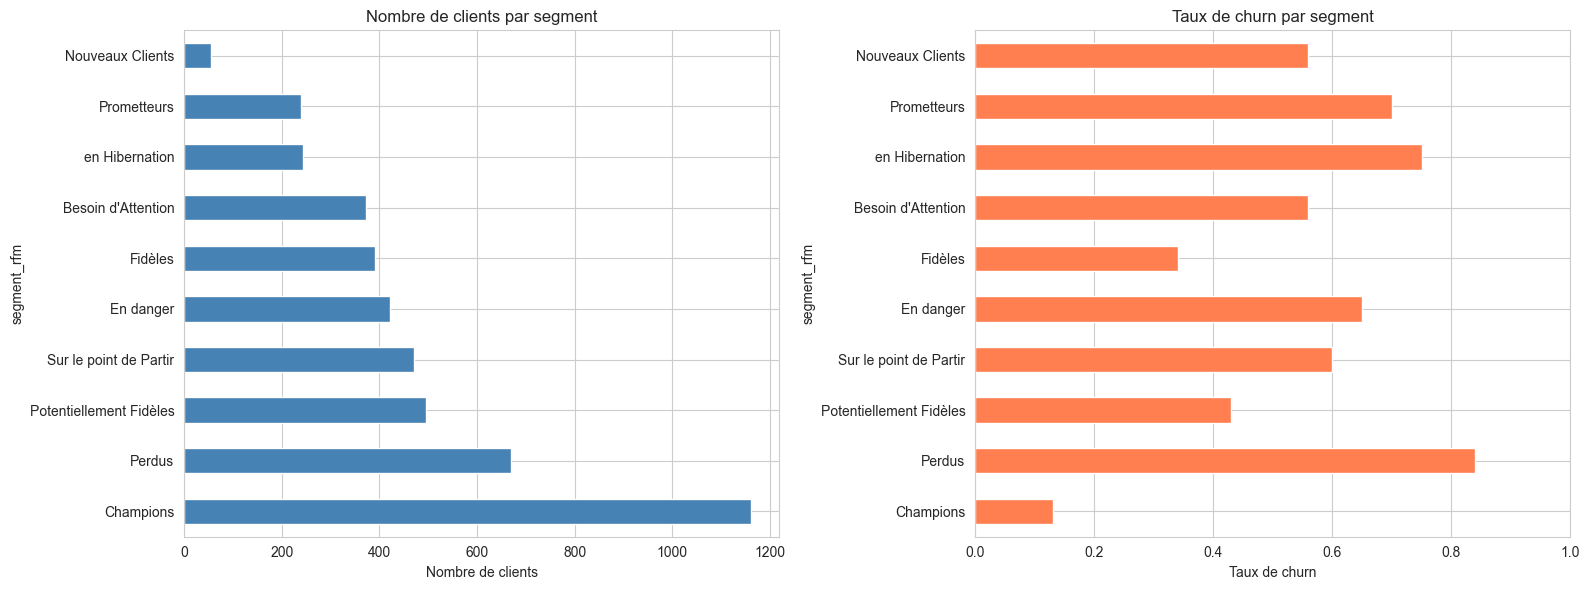

In [9]:
# Analyse churn par segment
segment_analysis = df.groupby('segment_rfm').agg(
    n_clients=('customer_id', 'count'),
    churn_rate=('churn', 'mean'),
    monetary_moy=('monetary', 'mean')
).round(2).sort_values('n_clients', ascending=False)

segment_analysis['pct_base'] = (segment_analysis['n_clients'] / len(df) * 100).round(1)

print("=== Analyse par segment RFM ===")
print(segment_analysis)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution
segment_analysis['n_clients'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Nombre de clients par segment")
axes[0].set_xlabel("Nombre de clients")

# Churn rate
segment_analysis['churn_rate'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Taux de churn par segment")
axes[1].set_xlabel("Taux de churn")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# PARTIE B — SEGMENTATION KMEANS

## 6. Préparation des données pour KMeans

Avant d'appliquer KMeans, deux étapes obligatoires :
1. **Gérer les NaN** : KMeans ne supporte pas les valeurs manquantes. 
   On impute `std_basket = 0` (logique pour les mono-acheteurs) et 
   `avg_interpurchase_days` par la médiane.
2. **Standardiser les features** : KMeans utilise la distance euclidienne. 
   Sans standardisation, une feature avec de gros chiffres (comme monetary) 
   dominerait toutes les autres.

### Quelles features on utilise ?
Toutes sauf : `customer_id` (identifiant), `churn` (cible interdite), 
`n_orders_future` (information du futur). Les scores RFM créés à la 
partie A sont aussi exclus pour ne pas biaiser KMeans.

In [11]:
# Features à utiliser pour KMeans
features_kmeans = [
    'recency', 'frequency', 'monetary',
    'avg_basket', 'std_basket', 'n_distinct_products',
    'tenure_days', 'avg_interpurchase_days',
    'n_cancellations', 'cancellation_rate'
]

X = df[features_kmeans].copy()

# Imputation des NaN
X['std_basket'] = X['std_basket'].fillna(0)
X['avg_interpurchase_days'] = X['avg_interpurchase_days'].fillna(X['avg_interpurchase_days'].median())

print(f"NaN restants : {X.isna().sum().sum()}")

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données standardisées : moyenne ≈ 0, écart-type ≈ 1")
print(f"   Shape : {X_scaled.shape}")

NaN restants : 0
Données standardisées : moyenne ≈ 0, écart-type ≈ 1
   Shape : (4518, 10)


## 7. Choix du nombre de clusters (méthode du coude)

KMeans demande de fixer **K** (le nombre de clusters) à l'avance. Comment 
choisir ? On utilise la **méthode du coude** :

1. On teste plusieurs valeurs de K (2 à 10)
2. Pour chaque K, on mesure l'**inertie** (= à quel point les points sont 
   loin de leur cluster). Plus K augmente, plus l'inertie baisse.
3. On cherche le **"coude"** sur la courbe : le K où ajouter un cluster 
   n'apporte plus grand-chose


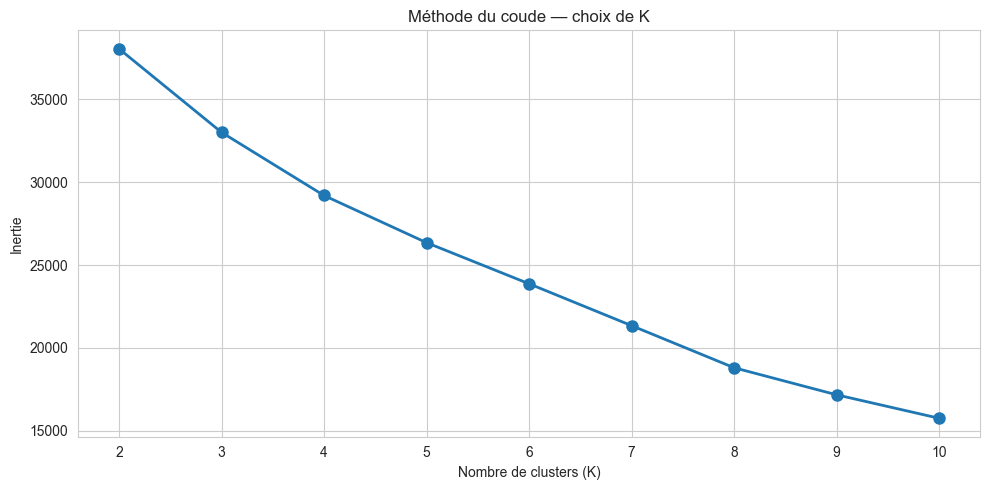

Inerties :
  K=2 : 38051
  K=3 : 33010
  K=4 : 29199
  K=5 : 26354
  K=6 : 23873
  K=7 : 21347
  K=8 : 18807
  K=9 : 17173
  K=10 : 15757


In [12]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
ax.set_xlabel("Nombre de clusters (K)")
ax.set_ylabel("Inertie")
ax.set_title("Méthode du coude — choix de K")
ax.set_xticks(K_range)
plt.tight_layout()
plt.show()

print("Inerties :")
for k, inertia in zip(K_range, inertias):
    print(f"  K={k} : {inertia:.0f}")

## 8. Entraînement du KMeans final

On choisit **K = 4** comme valeur par défaut (typiquement bon compromis 
sur du RFM). Si ton graphique du coude suggère une autre valeur (3 ou 5), 
ajuste la variable `K_OPTIMAL` ci-dessous.

On entraîne le modèle et on attribue à chaque client son numéro de cluster.